# Guided DDIM Reconstruction for Limited-Angle CT (LaDiff)

This notebook tests the trained **ladiff** diffusion model using the DDIM pipeline
with sinogram guidance. The diffusion prior (unconditional) is combined with a
gradient-descent data-consistency step at each denoising iteration, enforcing
agreement with the measured limited-angle projections.

**Pipeline overview:**
1. Load the limited-angle data for a chosen time-frame.
2. Reconstruct a *ground truth* from the **full** sinogram (FBP / GD).
3. Run DDIM with sinogram guidance using only the **limited-angle** projections.
4. Compare the guided reconstruction to the ground truth (PSNR, SSIM).

## 1. Imports and Setup

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset
from sdate.limited_angle_tomo import (
    LimitedAngleConfig, build_limited_angle_dataset, BaseLimitedAngleReconstructions
)
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline

# ── Reconstruction (2D parallel beam via lamino with angle=0) ─────────────
from astra_torch.lamino import (
    fbp_reconstruction_masked,
    gd_reconstruction_masked,
)

# ── Diffusion model / pipeline ────────────────────────────────────────────
from diffusers.models import UNet2DModel
from chip.models.tomographic_cbct_diffusion import GuidanceConfig

# ── Metrics ────────────────────────────────────────────────────────────────
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

# ── Laminography angle for standard 2D parallel-beam CT ───────────────────
LAMINO_ANGLE_DEG = 0.0

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")

zarr not installed


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ h5py available
⚠ SimpleITK not found. Install with: pip install SimpleITK
Device: cuda  |  PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe


## 2. Configuration

Parameters must match the training command:
```
python train_ladiff.py --num_projections 1501 --target_height 640 --target_width 540 \
    --image_size 540 --n_slices 500 --k_angles 400 --epochs 30 --batch_size 3 \
    --data_path /myhome/data/sdate/shared/compression_paper/file_1_extracted
```

In [2]:
import json

# ── Data ──────────────────────────────────────────────────────────────────
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 1501
TARGET_SIZE = (640, 540)

# ── Limited-angle tomography ──────────────────────────────────────────────
N_SLICES = 500
K_ANGLES = 400

# ── CT geometry ───────────────────────────────────────────────────────────
DET_SPACING_MM = 1.0
VOXEL_SIZE_MM = 1.0
IMAGE_SIZE = 640  # reconstruction is (IMAGE_SIZE, IMAGE_SIZE)

# ── Model ─────────────────────────────────────────────────────────────────
CHECKPOINT_PATH = str(project_root / 'checkpoints' / 'ddpm_ladiff.pt')

# ── Test frame ────────────────────────────────────────────────────────────
TEST_SLICE_IDX = 400  # which time-slice to test (0 .. N_SLICES-1)

# ── DDIM inference ────────────────────────────────────────────────────────
NUM_INFERENCE_STEPS = 50

# ── NUM_FRAMES number of frames to generate in each inference ────────────────────────────────────────────────────────
NUM_FRAMES = 5

# ── GAP Stride between consecutive window start indices
GAP = 20


# ── Normalization ─────────────────────────────────────────────────────────
# Load norm_scale from the dataset's cached config or the checkpoint sidecar
NORM_SCALE = 1.0
for norm_path in [
    DATA_PATH / 'ladiff_norm_config.json',
    Path(CHECKPOINT_PATH.replace('.pt', '_norm.json')),
]:
    if norm_path.exists():
        with open(norm_path) as f:
            NORM_SCALE = float(json.load(f)['norm_scale'])
        print(f"  Loaded norm_scale = {NORM_SCALE:.4f} from {norm_path}")
        break
else:
    print("  ⚠ No normalization config found — using norm_scale=1.0")

normalize_fn = lambda x: x * NORM_SCALE
denormalize_fn = lambda x: x / NORM_SCALE

print("Configuration set ✅")
print(f"  Data:       {DATA_PATH}")
print(f"  Slices:     {N_SLICES}")
print(f"  Angles/sl:  {K_ANGLES}")
print(f"  Test slice: {TEST_SLICE_IDX}")
print(f"  Checkpoint: {CHECKPOINT_PATH}")
print(f"  Norm scale: {NORM_SCALE:.4f}")

  Loaded norm_scale = 342.1634 from /myhome/data/sdate/shared/compression_paper/file_1_extracted/ladiff_norm_config.json
Configuration set ✅
  Data:       /myhome/data/sdate/shared/compression_paper/file_1_extracted
  Slices:     500
  Angles/sl:  400
  Test slice: 400
  Checkpoint: /myhome/sdate/checkpoints/ddpm_ladiff.pt
  Norm scale: 342.1634


## 3. Load Data and Build Limited-Angle Dataset

In [3]:
la_recons_dataset = BaseLimitedAngleReconstructions(
    data_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    n_slices=N_SLICES,
    k_angles=K_ANGLES,
    angular_range_deg=(0.0, 180.0),
    det_spacing_mm=DET_SPACING_MM,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    num_frames=NUM_FRAMES,
    gap=GAP,
    height_skip=0,  # skip 0 pixels from top and bottom of the volume (to avoid artifacts near the edges
)


dataset = la_recons_dataset.get_projection_slice_dataset()

la_data = la_recons_dataset.la_data

volume = dataset.get_full_volume()  # (H, W, N_proj)
H_vol, W_vol, N_proj = volume.shape
print(f"Volume shape: ({H_vol}, {W_vol}, {N_proj})")

Install with: pip install pillow-heif
✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: True
✅ Loaded cached attenuation data from .tomography_cache_atten.npz
   Range: [-0.1997, 1.7837]
ProjectionSliceDataset:
  Volume shape: (540, 640, 1501)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 345,600
Loading 1501 projections...
  Loaded 50/1501
  Loaded 100/1501
  Loaded 150/1501
  Loaded 200/1501
  Loaded 250/1501
  Loaded 300/1501
  Loaded 350/1501
  Loaded 400/1501
  Loaded 450/1501
  Loaded 500/1501
  Loaded 550/1501
  Loaded 600/1501
  Loaded 650/1501
  Loaded 700/1501
  Loaded 750/1501
  Loaded 800/1501
  Loaded 850/1501
  Loaded 900/1501
  Loaded 950/1501
  Loaded 1000/1501
  Loaded 1050/1501
  Loaded 1100/1501
  Loaded 1150/1501
  Loaded 1200/1501
  Loaded 12

/myhome/sdate/sdate/limited_angle_tomo.py:428: UserWarning: [BaseLimitedAngleReconstructions] Using cached normalization scale = 342.1634 (from /myhome/data/sdate/shared/compression_paper/file_1_extracted/ladiff_norm_config.json). Reconstructions will be multiplied by this factor to map them to ~[0, 1].
  self.norm_scale: float = self._calibrate_normalization(data_path)


Volume shape: (540, 640, 1501)


## 4. Select Test Frame

Extract the full sinogram and limited-angle sinogram for the chosen time-slice.

In [4]:
TEST_SLICE_IDX = 60  # first time-slice of the multi-frame window

# Retrieve per-frame data for NUM_FRAMES consecutive slices
frame_data = la_recons_dataset.get_multiframe_data(TEST_SLICE_IDX)

slice_indices = frame_data["slice_indices"]
full_sinos    = frame_data["full_sinograms"]       # list of (total_proj, W)
limited_sinos = frame_data["limited_sinograms"]     # list of (k_angles, W)
limited_angles_list = frame_data["limited_angles_deg"]  # list of (k_angles,) np
all_angles    = frame_data["all_angles_deg"]        # (total_proj,) np

W = la_data.W
vol_shape_2d = (1, W, W)  # (nz=1, ny, nx) for 2D parallel beam

print(f"Multi-frame test: {NUM_FRAMES} frames starting at slice {TEST_SLICE_IDX}")
for f, t in enumerate(slice_indices):
    print(f"  Frame {f}: slice {t}  |  "
          f"limited sino {limited_sinos[f].shape}  |  "
          f"angles {limited_angles_list[f][0]:.1f}° – {limited_angles_list[f][-1]:.1f}°")

Multi-frame test: 5 frames starting at slice 60
  Frame 0: slice 60  |  limited sino torch.Size([400, 640])  |  angles 178.1° – 45.9°
  Frame 1: slice 61  |  limited sino torch.Size([400, 640])  |  angles 46.0° – 93.9°
  Frame 2: slice 62  |  limited sino torch.Size([400, 640])  |  angles 94.0° – 141.9°
  Frame 3: slice 63  |  limited sino torch.Size([400, 640])  |  angles 142.0° – 9.8°
  Frame 4: slice 64  |  limited sino torch.Size([400, 640])  |  angles 10.0° – 57.8°


## 5. Ground Truth: Full-Angle Reconstruction

Reconstruct the ground truth from **all** projections using FBP.
This is only available for testing purposes.

  Frame 0 (slice 60): GT torch.Size([640, 640]) [-0.0016, 0.0045]  in 0.1s
  Frame 1 (slice 61): GT torch.Size([640, 640]) [-0.0019, 0.0044]  in 0.1s
  Frame 2 (slice 62): GT torch.Size([640, 640]) [-0.0018, 0.0041]  in 0.1s
  Frame 3 (slice 63): GT torch.Size([640, 640]) [-0.0017, 0.0042]  in 0.1s
  Frame 4 (slice 64): GT torch.Size([640, 640]) [-0.0016, 0.0044]  in 0.1s


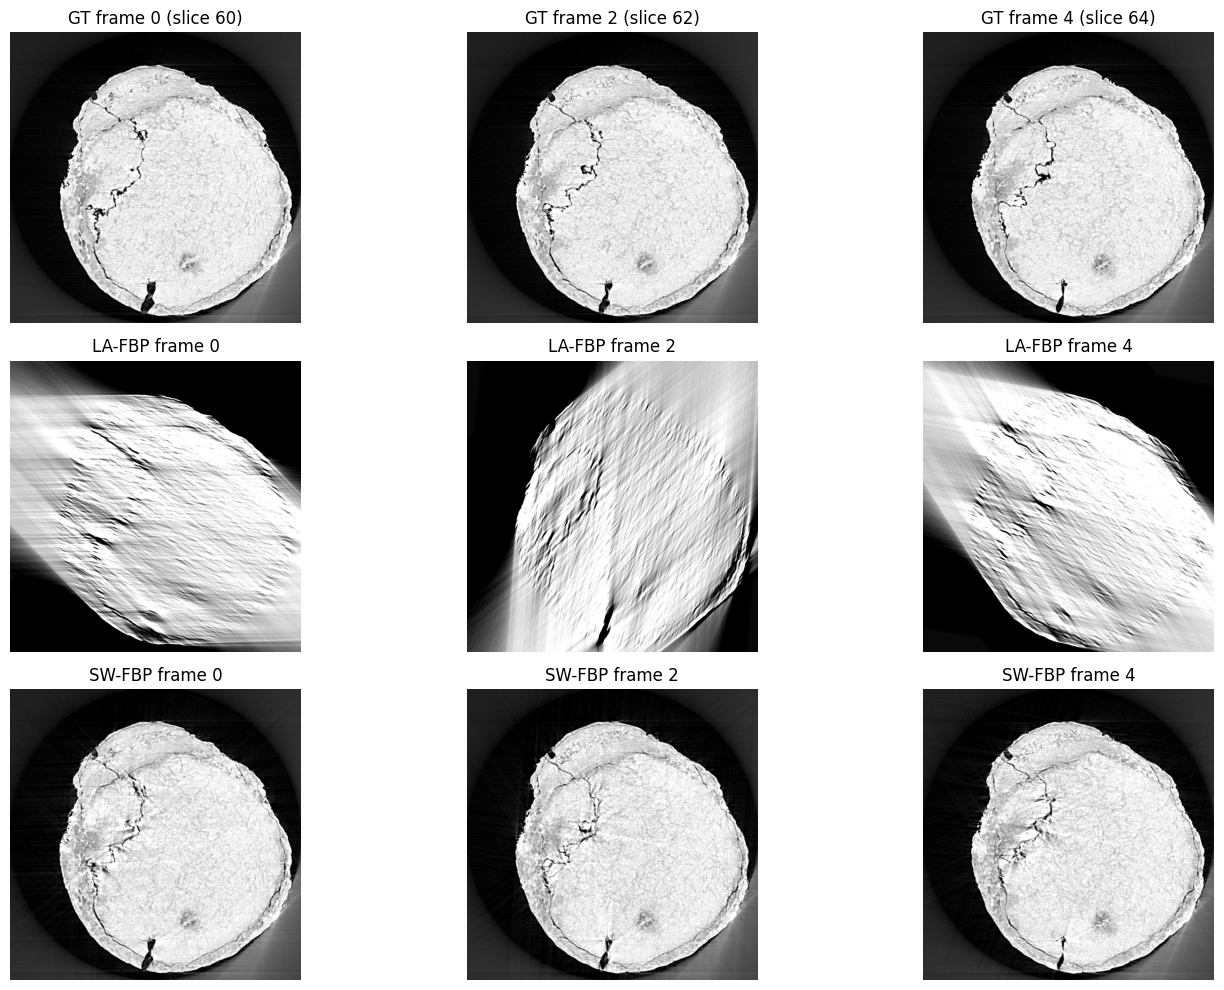

In [5]:
sw_fbps = denormalize_fn(la_recons_dataset[TEST_SLICE_IDX * GAP].squeeze())
# FBP ground truths from full sinograms (one per frame)
gt_recons = []
la_fbps = []

for f in range(NUM_FRAMES):
    t0 = time.time()
    gt_f = fbp_reconstruction_masked(
        projs_vrc=full_sinos[f].unsqueeze(1).to(device),  # (total_proj, 1, W)
        angles_deg=all_angles,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_2d,
        det_spacing_mm=DET_SPACING_MM,
        filter_type='hann',
        device=device,
    ).squeeze(0)  # (ny, nx)
    gt_recons.append(gt_f)

    la_f = fbp_reconstruction_masked(
        projs_vrc=limited_sinos[f].unsqueeze(1).to(device),
        angles_deg=limited_angles_list[f],
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_2d,
        det_spacing_mm=DET_SPACING_MM,
        filter_type='hann',
        device=device,
    ).squeeze(0)
    la_fbps.append(la_f)
    print(f"  Frame {f} (slice {slice_indices[f]}): GT {gt_f.shape} "
          f"[{gt_f.min():.4f}, {gt_f.max():.4f}]  in {time.time()-t0:.1f}s")

gt_recons_t = torch.stack(gt_recons)   # (NUM_FRAMES, ny, nx)
la_fbps_t = torch.stack(la_fbps)       # (NUM_FRAMES, ny, nx)

# Visualise first, middle, last frames
show_idx = [0, NUM_FRAMES // 2, NUM_FRAMES - 1] if NUM_FRAMES >= 3 else list(range(NUM_FRAMES))
fig, axes = plt.subplots(3, len(show_idx), figsize=(5 * len(show_idx), 10))
if len(show_idx) == 1:
    axes = axes.reshape(-1, 1)
for col, f in enumerate(show_idx):
    vmin, vmax = np.percentile(gt_recons[f].cpu().numpy(), [2, 98])
    axes[0, col].imshow(gt_recons[f].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'GT frame {f} (slice {slice_indices[f]})')
    axes[0, col].axis('off')
    axes[1, col].imshow(la_fbps[f].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'LA-FBP frame {f}')
    axes[1, col].axis('off')
    axes[2, col].imshow(sw_fbps[f].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, col].set_title(f'SW-FBP frame {f}')
    axes[2, col].axis('off')
plt.tight_layout()
plt.show()

## 6. Load Trained Diffusion Model

In [6]:
CHECKPOINT_PATH = str(project_root / 'checkpoints' / 'ddpm_ladiff3d.pt')
# Build the same architecture used during training
channels = (64, 64, 128, 128, 256, 256)
model = UNet2DModel(
    sample_size=gt_recons_t.shape[1:],
    in_channels=NUM_FRAMES,
    out_channels=NUM_FRAMES,
    layers_per_block=2,
    block_out_channels=channels,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D",
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
        "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
).to(device)

# Load checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  in_channels={NUM_FRAMES}, out_channels={NUM_FRAMES}")

Model loaded from /myhome/sdate/checkpoints/ddpm_ladiff3d.pt
  Parameters: 28,449,541
  in_channels=5, out_channels=5


## 7. Define Guidance Function (2D Parallel Beam)

The guidance function enforces data consistency at each DDIM step by running a
few gradient-descent iterations of `gd_reconstruction_masked` from
`astra_torch.lamino` (2D parallel beam geometry with `lamino_angle=0`).

In [7]:
def sinogram_guidance_multiframe(
    projs_list: list,            # list of (k_angles, 1, W) tensors, one per frame
    angles_list: list,           # list of (k_angles,) numpy arrays, one per frame
    vol_init: torch.Tensor,      # (num_frames, H, W) — current denoised estimate
    max_epochs: int = 5,
    lr: float = 0.5,
    batch_size: int = 30,
    verbose: bool = False,
) -> torch.Tensor:
    """Apply per-frame GD guidance using each frame's own limited-angle data.

    Parameters
    ----------
    projs_list : list of (k_i, 1, W) tensors
        Limited-angle projections for each frame.
    angles_list : list of (k_i,) numpy arrays
        Corresponding projection angles for each frame.
    vol_init : (num_frames, H, W)
        Current predicted x_0 (all frames stacked).

    Returns
    -------
    recon : (num_frames, H, W)
    """
    num_frames = vol_init.shape[0]
    frames_out = []
    for f in range(num_frames):
        recon_f = gd_reconstruction_masked(
            projs_vrc=projs_list[f],
            angles_deg=angles_list[f],
            lamino_angle_deg=LAMINO_ANGLE_DEG,
            vol_shape=(1, vol_init.shape[1], vol_init.shape[2]),
            det_spacing_mm=DET_SPACING_MM,
            vol_init=vol_init[f : f + 1],   # (1, H, W)
            max_epochs=max_epochs,
            lr=lr,
            batch_size=batch_size,
            clamp_min=0.0,
            device=vol_init.device,
            verbose=verbose and (f == 0),
        )  # (1, H, W)
        frames_out.append(recon_f)
    return torch.cat(frames_out, dim=0)  # (num_frames, H, W)


# Prepare per-frame measurement tensors (move to device once)
meas_projs_list = [s.unsqueeze(1).to(device) for s in limited_sinos]    # list of (k, 1, W)
meas_angles_list = [a.copy() for a in limited_angles_list]              # list of (k,) numpy

  0%|          | 0/10 [00:00<?, ?it/s, loss=9.258e-02, avg=2.263e-01, k=30, lr=1.0e-03, opt=ADAM]

[0.001] [10]


100%|██████████| 10/10 [00:01<00:00,  7.26it/s, loss=4.676e-05, avg=7.108e-05, k=10, lr=1.0e-03, opt=ADAM]


Guidance test output: torch.Size([5, 640, 640])


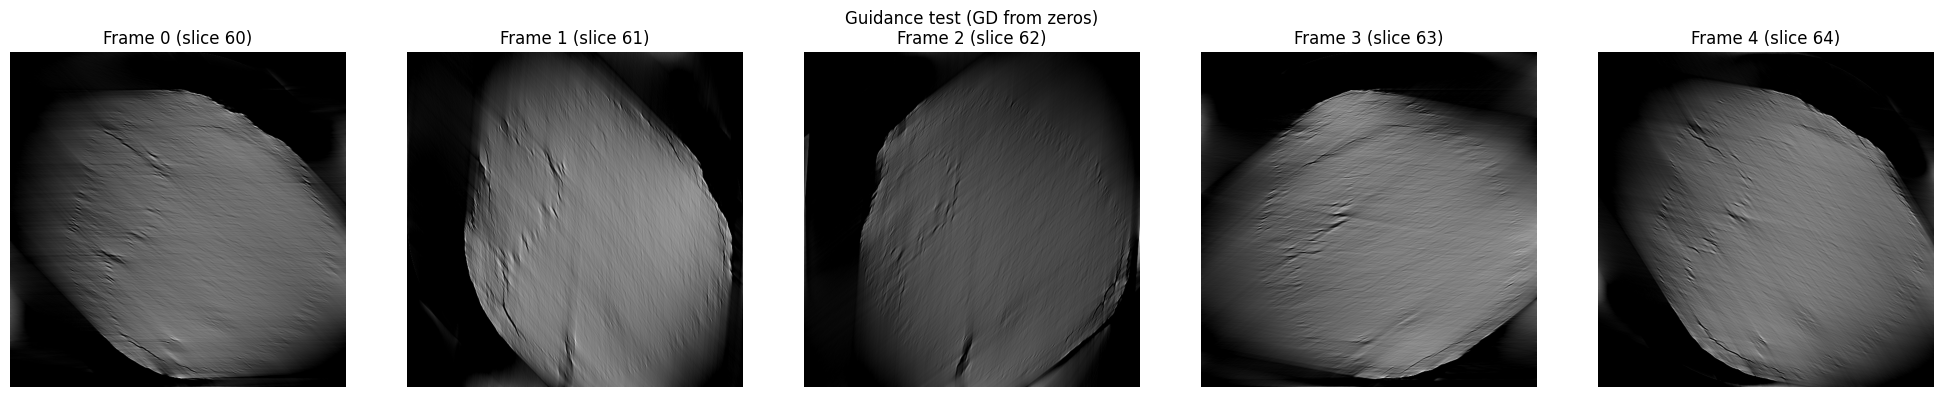

In [8]:
# Quick test: guidance from zero initialization
guidance_test = lambda x, t: sinogram_guidance_multiframe(
    projs_list=meas_projs_list,
    angles_list=meas_angles_list,
    vol_init=x.to(device),
    max_epochs=[10],
    lr=[0.001],
    batch_size=30,
    verbose=True,
)

recon_test = guidance_test(torch.zeros(NUM_FRAMES, gt_recons[0].shape[0], gt_recons[0].shape[1], device=device), t=900)
print(f"Guidance test output: {recon_test.shape}")

# Plot all frames
fig, axes = plt.subplots(1, NUM_FRAMES, figsize=(4 * NUM_FRAMES, 4))
if NUM_FRAMES == 1:
    axes = [axes]
for i in range(NUM_FRAMES):
    axes[i].imshow(recon_test[i].cpu().numpy(), cmap='gray')
    axes[i].set_title(f"Frame {i} (slice {slice_indices[i]})")
    axes[i].axis('off')
plt.suptitle("Guidance test (GD from zeros)")
plt.tight_layout()
plt.show()

## 8. Run DDIM Pipeline with Guidance

In [9]:
# Guidance hyperparameters
GUIDANCE_EPOCHS = [1]
GUIDANCE_LR = [0.00005]
GUIDANCE_BATCH_SIZE = 30

# Build the guidance lambda for the scheduler
# Input: (num_frames, H, W) — each frame gets its own limited-angle guidance
guidance = lambda x, t: sinogram_guidance_multiframe(
    projs_list=meas_projs_list,
    angles_list=meas_angles_list,
    vol_init=x.to(device),
    max_epochs=GUIDANCE_EPOCHS,
    lr=GUIDANCE_LR,
    batch_size=GUIDANCE_BATCH_SIZE,
)

print(f"Guidance ready: {NUM_FRAMES} frames, "
      f"{GUIDANCE_EPOCHS} GD epochs/step, lr={GUIDANCE_LR}")
for f in range(NUM_FRAMES):
    print(f"  Frame {f}: {meas_projs_list[f].shape[0]} angles "
          f"[{meas_angles_list[f][0]:.1f}° – {meas_angles_list[f][-1]:.1f}°]")

Guidance ready: 5 frames, [1] GD epochs/step, lr=[5e-05]
  Frame 0: 400 angles [178.1° – 45.9°]
  Frame 1: 400 angles [46.0° – 93.9°]
  Frame 2: 400 angles [94.0° – 141.9°]
  Frame 3: 400 angles [142.0° – 9.8°]
  Frame 4: 400 angles [10.0° – 57.8°]


In [10]:
import sys, importlib
# Reload to pick up edits without restarting the kernel
import ladiff.schedulers.scheduling_ddim  as _scheduling_ddim_mod
importlib.reload(_scheduling_ddim_mod)

import ladiff.schedulers.pipeline_ddim  as _pipeline_mod
importlib.reload(_pipeline_mod)

from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline



In [11]:
from diffusers.schedulers import DDIMScheduler
from diffusers.pipelines import DDIMPipeline

torch.cuda.empty_cache()
NUM_INFERENCE_STEPS = 50

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
)

pipeline = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler,
)

t0 = time.time()
result = pipeline(
    batch_size=1,                       # single 2D slice: (1, H, W)
    num_inference_steps=NUM_INFERENCE_STEPS,
)
result.images[0]


100%|██████████| 50/50 [00:02<00:00, 17.97it/s]


TypeError: Cannot handle this data type: (1, 1, 5), |u1

In [ ]:
torch.cuda.empty_cache()
NUM_INFERENCE_STEPS = 100

noise_scheduler = GuidedDDIMScheduler(
    num_train_timesteps=1000,
    guidance_function=guidance,
    # clip_sample=True,  # model was trained on raw FBP values, not [-1,1]
)

pipeline = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler,
    fdk_prior=None,           # unconditional
    normalize_fn=normalize_fn,   # raw → normalized (×norm_scale)
    denormalize_fn=denormalize_fn, # normalized → raw (÷norm_scale)
    slice_batch_size=2,       # single 2D slice
)

t0 = time.time()
result = pipeline(
    batch_size=NUM_FRAMES,             # single slice: image shape = (1, H, W)
    num_inference_steps=NUM_INFERENCE_STEPS,
    eta=0.0,                  # deterministic DDIM
)
diffusion_recon = result.images.squeeze(0).cpu()  # (H, W)
dt = time.time() - t0

print(f"Guided DDIM reconstruction done in {dt:.1f}s")
print(f"  shape: {diffusion_recon.shape}")
print(f"  range: [{diffusion_recon.min():.4f}, {diffusion_recon.max():.4f}]")

## 9. Compare and Compute Metrics

In [ ]:
# Per-frame metrics: DDIM vs GT
diff_np = diffusion_recon.numpy()   # (NUM_FRAMES, H, W)

ncols = NUM_FRAMES
fig, axes = plt.subplots(4, ncols, figsize=(5 * ncols, 20))
if ncols == 1:
    axes = axes.reshape(-1, 1)

for f in range(NUM_FRAMES):
    gt_f = gt_recons[f].cpu().numpy()
    ddim_f = diff_np[f]
    la_f = la_fbps[f].cpu().numpy()
    sw_f = sw_fbps[f].cpu().numpy()
    vmin, vmax = np.percentile(gt_f, [2, 98])
    data_range = gt_f.max() - gt_f.min()

    psnr_ddim = compute_psnr(gt_f, ddim_f, data_range=data_range)
    psnr_la = compute_psnr(gt_f, la_f, data_range=data_range)
    psnr_sw = compute_psnr(gt_f, sw_f, data_range=data_range)

    axes[0, f].imshow(gt_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, f].set_title(f'GT frame {f}\n(slice {slice_indices[f]})')
    axes[0, f].axis('off')

    axes[1, f].imshow(ddim_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, f].set_title(f'DDIM frame {f}\nPSNR={psnr_ddim:.2f} dB')
    axes[1, f].axis('off')

    axes[2, f].imshow(sw_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, f].set_title(f'SW-FBP frame {f}\nPSNR={psnr_sw:.2f} dB')
    axes[2, f].axis('off')

    axes[3, f].imshow(la_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[3, f].set_title(f'LA-FBP frame {f}\nPSNR={psnr_la:.2f} dB')
    axes[3, f].axis('off')

plt.suptitle(f"Multi-frame Guided DDIM ({NUM_FRAMES} frames)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Detailed per-frame metrics table
print(f"{'Frame':>6} {'Slice':>6}  {'Method':<25} {'PSNR (dB)':>10} {'SSIM':>8}")
print("-" * 65)

psnr_ddim_list, ssim_ddim_list = [], []
psnr_la_list, ssim_la_list = [], []
psnr_sw_list, ssim_sw_list = [], []

for f in range(NUM_FRAMES):
    gt_f = gt_recons[f].cpu().numpy()
    ddim_f = diff_np[f]
    la_f = la_fbps[f].cpu().numpy()
    sw_f = sw_fbps[f].cpu().numpy()
    data_range = gt_f.max() - gt_f.min()

    p_ddim = compute_psnr(gt_f, ddim_f, data_range=data_range)
    s_ddim = compute_ssim(gt_f, ddim_f, data_range=data_range)
    p_la = compute_psnr(gt_f, la_f, data_range=data_range)
    s_la = compute_ssim(gt_f, la_f, data_range=data_range)
    p_sw = compute_psnr(gt_f, sw_f, data_range=data_range)
    s_sw = compute_ssim(gt_f, sw_f, data_range=data_range)

    psnr_ddim_list.append(p_ddim)
    ssim_ddim_list.append(s_ddim)
    psnr_la_list.append(p_la)
    ssim_la_list.append(s_la)
    psnr_sw_list.append(p_sw)
    ssim_sw_list.append(s_sw)

    print(f"{f:>6d} {slice_indices[f]:>6d}  {'Guided DDIM':<25} {p_ddim:>10.2f} {s_ddim:>8.4f}")
    print(f"{'':>6} {'':>6}  {'Limited-angle FBP':<25} {p_la:>10.2f} {s_la:>8.4f}")
    print(f"{'':>6} {'':>6}  {'SW-FBP':<25} {p_sw:>10.2f} {s_sw:>8.4f}")

print("-" * 65)
print(f"{'Mean':>13}  {'Guided DDIM':<25} {np.mean(psnr_ddim_list):>10.2f} {np.mean(ssim_ddim_list):>8.4f}")
print(f"{'':>13}  {'Limited-angle FBP':<25} {np.mean(psnr_la_list):>10.2f} {np.mean(ssim_la_list):>8.4f}")
print(f"{'':>13}  {'SW-FBP':<25} {np.mean(psnr_sw_list):>10.2f} {np.mean(ssim_sw_list):>8.4f}")


In [ ]:
# Side-by-side: GT | DDIM | LA-FBP | SW-FBP for select frames
show_idx = [0, NUM_FRAMES // 2, NUM_FRAMES - 1] if NUM_FRAMES >= 3 else list(range(NUM_FRAMES))
ncols = len(show_idx)
fig, axes = plt.subplots(4, ncols, figsize=(10 * ncols, 40))
if ncols == 1:
    axes = axes.reshape(-1, 1)

for col, f in enumerate(show_idx):
    gt_f = gt_recons[f].cpu().numpy()
    vmin, vmax = np.percentile(gt_f, [1, 99])

    axes[0, col].imshow(gt_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'Ground Truth\nFrame {f} (slice {slice_indices[f]})')
    axes[0, col].axis('off')

    axes[1, col].imshow(diff_np[f], cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'Guided DDIM\nPSNR={psnr_ddim_list[f]:.2f} dB  SSIM={ssim_ddim_list[f]:.4f}')
    axes[1, col].axis('off')

    axes[2, col].imshow(la_fbps[f].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, col].set_title(f'LA-FBP\nPSNR={psnr_la_list[f]:.2f} dB  SSIM={ssim_la_list[f]:.4f}')
    axes[2, col].axis('off')

    axes[3, col].imshow(sw_fbps[f].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[3, col].set_title(f'SW-FBP\nPSNR={psnr_sw_list[f]:.2f} dB  SSIM={ssim_sw_list[f]:.4f}')
    axes[3, col].axis('off')

plt.suptitle(f"Multi-frame reconstruction comparison ({NUM_FRAMES} frames)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Error maps: GT − DDIM and GT − SW-FBP for each frame
show_idx = [0, NUM_FRAMES // 2, NUM_FRAMES - 1] if NUM_FRAMES >= 3 else list(range(NUM_FRAMES))
ncols = len(show_idx)
fig, axes = plt.subplots(3, ncols, figsize=(5 * ncols, 15))
if ncols == 1:
    axes = axes.reshape(-1, 1)

for col, f in enumerate(show_idx):
    gt_f = gt_recons[f].cpu().numpy()
    vmin, vmax = np.percentile(gt_f, [1, 100])

    axes[0, col].imshow(diff_np[f], cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'DDIM frame {f}\nPSNR={psnr_ddim_list[f]:.2f} dB')
    axes[0, col].axis('off')

    err_ddim = gt_f - diff_np[f]
    err_range = max(abs(err_ddim.min()), abs(err_ddim.max()))
    axes[1, col].imshow(err_ddim, cmap='RdBu', vmin=-err_range, vmax=err_range)
    axes[1, col].set_title(f'Error (GT − DDIM) frame {f}')
    axes[1, col].axis('off')

    err_sw = gt_f - sw_fbps[f].cpu().numpy()
    err_sw_range = max(abs(err_sw.min()), abs(err_sw.max()))
    axes[2, col].imshow(err_sw, cmap='RdBu', vmin=-err_sw_range, vmax=err_sw_range)
    axes[2, col].set_title(f'Error (GT − SW-FBP) frame {f}\nPSNR={psnr_sw_list[f]:.2f} dB')
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()


## 10. Optional: Fine-tune with Extra GD Iterations

Run additional gradient-descent iterations on the diffusion output to further
improve data consistency with the measured projections.

In [ ]:
# Fine-tune each frame independently with extra GD iterations
recon_finetuned_list = []
for f in range(NUM_FRAMES):
    ft = gd_reconstruction_masked(
        projs_vrc=meas_projs_list[f],
        angles_deg=meas_angles_list[f],
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_2d,
        det_spacing_mm=DET_SPACING_MM,
        vol_init=diffusion_recon[f].unsqueeze(0).to(device),  # (1, H, W)
        max_epochs=10,
        lr=0.0001,
        batch_size=200,
        clamp_min=0.0,
        device=device,
        verbose=(f == 0),
    ).squeeze(0).cpu()  # (H, W)
    recon_finetuned_list.append(ft)

recon_ft_np = np.stack([r.numpy() for r in recon_finetuned_list])  # (NUM_FRAMES, H, W)

psnr_ft_list, ssim_ft_list = [], []
for f in range(NUM_FRAMES):
    gt_f = gt_recons[f].cpu().numpy()
    data_range = gt_f.max() - gt_f.min()
    psnr_ft_list.append(compute_psnr(gt_f, recon_ft_np[f], data_range=data_range))
    ssim_ft_list.append(compute_ssim(gt_f, recon_ft_np[f], data_range=data_range))

print(f"\n{'Frame':>6} {'Slice':>6}  {'Method':<30} {'PSNR (dB)':>10} {'SSIM':>8}")
print("-" * 70)
for f in range(NUM_FRAMES):
    print(f"{f:>6d} {slice_indices[f]:>6d}  {'Guided DDIM':<30} {psnr_ddim_list[f]:>10.2f} {ssim_ddim_list[f]:>8.4f}")
    print(f"{'':>6} {'':>6}  {'DDIM + GD fine-tune':<30} {psnr_ft_list[f]:>10.2f} {ssim_ft_list[f]:>8.4f}")
    print(f"{'':>6} {'':>6}  {'Limited-angle FBP':<30} {psnr_la_list[f]:>10.2f} {ssim_la_list[f]:>8.4f}")
    print(f"{'':>6} {'':>6}  {'SW-FBP':<30} {psnr_sw_list[f]:>10.2f} {ssim_sw_list[f]:>8.4f}")
print("-" * 70)
print(f"{'Mean':>13}  {'Guided DDIM':<30} {np.mean(psnr_ddim_list):>10.2f} {np.mean(ssim_ddim_list):>8.4f}")
print(f"{'':>13}  {'DDIM + GD fine-tune':<30} {np.mean(psnr_ft_list):>10.2f} {np.mean(ssim_ft_list):>8.4f}")
print(f"{'':>13}  {'Limited-angle FBP':<30} {np.mean(psnr_la_list):>10.2f} {np.mean(ssim_la_list):>8.4f}")
print(f"{'':>13}  {'SW-FBP':<30} {np.mean(psnr_sw_list):>10.2f} {np.mean(ssim_sw_list):>8.4f}")


In [ ]:
# Fine-tuning comparison for select frames
show_idx = [0, NUM_FRAMES // 2, NUM_FRAMES - 1] if NUM_FRAMES >= 3 else list(range(NUM_FRAMES))
ncols = len(show_idx)
fig, axes = plt.subplots(5, ncols, figsize=(6 * ncols, 30))
if ncols == 1:
    axes = axes.reshape(-1, 1)

for col, f in enumerate(show_idx):
    gt_f = gt_recons[f].cpu().numpy()
    vmin, vmax = np.percentile(gt_f, [1, 99])

    axes[0, col].imshow(gt_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'GT frame {f}')
    axes[0, col].axis('off')

    axes[1, col].imshow(la_fbps[f].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'LA-FBP\nPSNR={psnr_la_list[f]:.2f}  SSIM={ssim_la_list[f]:.4f}')
    axes[1, col].axis('off')

    axes[2, col].imshow(sw_fbps[f].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, col].set_title(f'SW-FBP\nPSNR={psnr_sw_list[f]:.2f}  SSIM={ssim_sw_list[f]:.4f}')
    axes[2, col].axis('off')

    axes[3, col].imshow(diff_np[f], cmap='gray', vmin=vmin, vmax=vmax)
    axes[3, col].set_title(f'DDIM\nPSNR={psnr_ddim_list[f]:.2f}  SSIM={ssim_ddim_list[f]:.4f}')
    axes[3, col].axis('off')

    axes[4, col].imshow(recon_ft_np[f], cmap='gray', vmin=vmin, vmax=vmax)
    axes[4, col].set_title(f'DDIM+GD\nPSNR={psnr_ft_list[f]:.2f}  SSIM={ssim_ft_list[f]:.4f}')
    axes[4, col].axis('off')

plt.suptitle(f"Fine-tuning comparison ({NUM_FRAMES} frames)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Browse all frames: DDIM reconstruction filmstrip
fig, axes = plt.subplots(1, NUM_FRAMES, figsize=(4 * NUM_FRAMES, 4))
if NUM_FRAMES == 1:
    axes = [axes]
vmin, vmax = np.percentile(gt_recons[0].cpu().numpy(), [1, 99])
for f in range(NUM_FRAMES):
    axes[f].imshow(diff_np[f], cmap='gray', vmin=vmin, vmax=vmax)
    axes[f].set_title(f"Frame {f}\n(slice {slice_indices[f]})")
    axes[f].axis('off')
plt.suptitle("DDIM reconstructions — all frames", fontsize=13)
plt.tight_layout()
plt.show()